# House Prices: Feature Engineering

**Joselyne**

This notebook builds a complete feature-engineering and regression workflow for the Kaggle House Prices dataset.

### Approach
- Interpret missing values based on what they mean.
- Treat `MSSubClass` as categorical, not numerical.
- Use ordinal encoding for ordered categories.
- Use one-hot encoding for nominal categories.
- Compare Linear Regression and Random Forest.
- Validate the workflow without data leakage.
- Use `log1p(SalePrice)` to reduce target skew and match the competition metric.


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction import FeatureHasher
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

warnings.filterwarnings(
    "ignore",
    message="Found unknown categories.*during transform"
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [43]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Initial Data Inspection

I first check the dataset shape, data types, duplicates and missing values. This gives a clear view of the data before preprocessing.


In [44]:
print("Duplicate rows in train:", train.duplicated().sum())
print("\nData types:")
display(train.dtypes.value_counts().rename("count").to_frame())

missing_before = train.isna().sum().sort_values(ascending=False)
missing_before = missing_before[missing_before > 0]
print("\nColumns with missing values:", len(missing_before))
display(missing_before.head(20).to_frame("missing_count"))

Duplicate rows in train: 0

Data types:


,count
object,43
int64,35
float64,3



Columns with missing values: 19


,missing_count
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


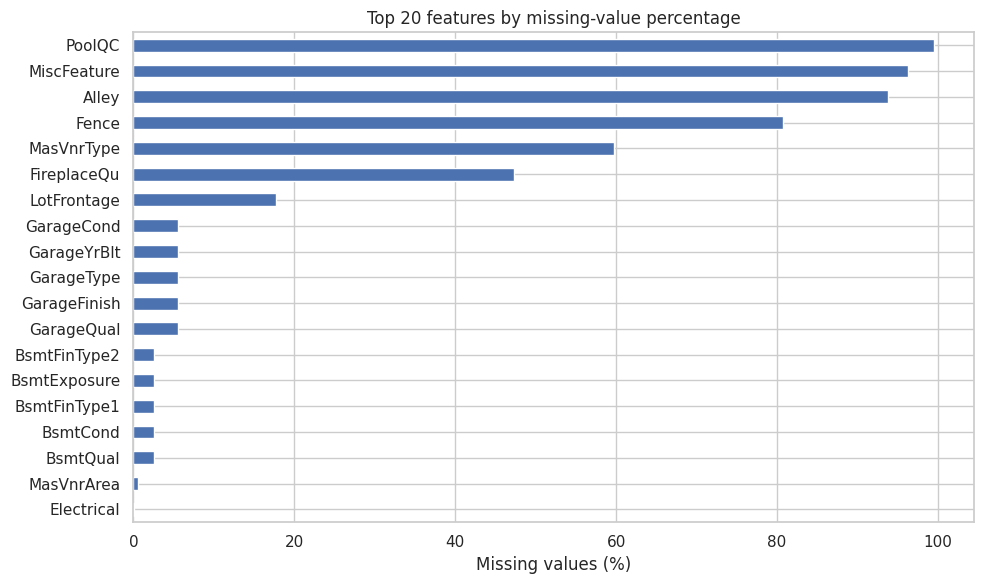

In [45]:
plt.figure(figsize=(10, 6))
missing_pct = (train.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0].head(20)
missing_pct.sort_values().plot(kind="barh")
plt.xlabel("Missing values (%)")
plt.title("Top 20 features by missing-value percentage")
plt.tight_layout()
plt.show()

## 2. Target Distribution

`SalePrice` is right-skewed, so I use `log1p(SalePrice)` as the modelling target. This reduces the effect of extreme prices and matches the competition's log-scale evaluation.


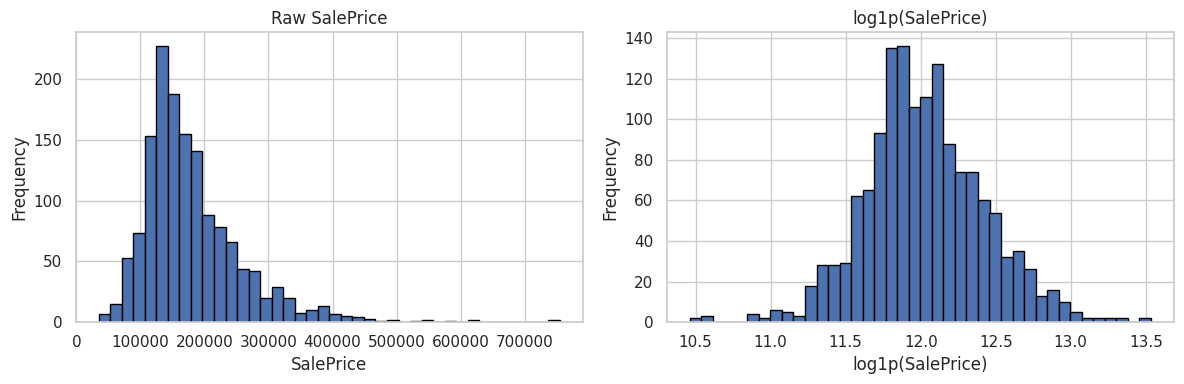

In [46]:
y = train["SalePrice"]
y_log = np.log1p(y)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=40, edgecolor="black")
axes[0].set_title("Raw SalePrice")
axes[0].set_xlabel("SalePrice")
axes[0].set_ylabel("Frequency")

axes[1].hist(y_log, bins=40, edgecolor="black")
axes[1].set_title("log1p(SalePrice)")
axes[1].set_xlabel("log1p(SalePrice)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 3. Missing-Value Reasoning

Not all missing values mean the same thing.

- For optional house features such as a garage, basement or pool, `NaN` can mean the feature is **not present**. These are represented as `None` for categories and `0` for numeric values.
- For other missing values, the actual value is unknown. These are imputed using the median for numeric features and the most frequent category for categorical features.

The preprocessing rules are learned from the training data only.


In [47]:
# Categorical columns where missing means the feature/component is absent.
absence_categorical = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType"
]

# Numeric columns where missing means the corresponding component does not exist.
absence_numeric = [
    "GarageYrBlt", "GarageArea", "GarageCars", "BsmtFinSF1", "BsmtFinSF2",
    "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath", "MasVnrArea"
]

print("Categorical absence columns:", len(absence_categorical))
print(absence_categorical)
print("\nNumeric absence columns:", len(absence_numeric))
print(absence_numeric)

Categorical absence columns: 15
['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']

Numeric absence columns: 10
['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']


## 4. Correct Variable Types Before Encoding

`MSSubClass` contains building-class codes rather than a measurable quantity. Although it is stored as an integer, it should be treated as a **nominal categorical feature** before encoding.


In [48]:
X = train.drop(columns="SalePrice").copy()
X_test = test.copy()

# Treat MSSubClass as categorical before encoding.
X["MSSubClass"] = X["MSSubClass"].astype(str)
X_test["MSSubClass"] = X_test["MSSubClass"].astype(str)

print("MSSubClass dtype after correction:", X["MSSubClass"].dtype)
print("Example classes:", sorted(X["MSSubClass"].dropna().unique())[:10])

MSSubClass dtype after correction: object
Example classes: ['120', '160', '180', '190', '20', '30', '40', '45', '50', '60']


## 5. Exploratory Visualizations

These plots show how key features relate to house prices and help identify useful patterns before modelling.


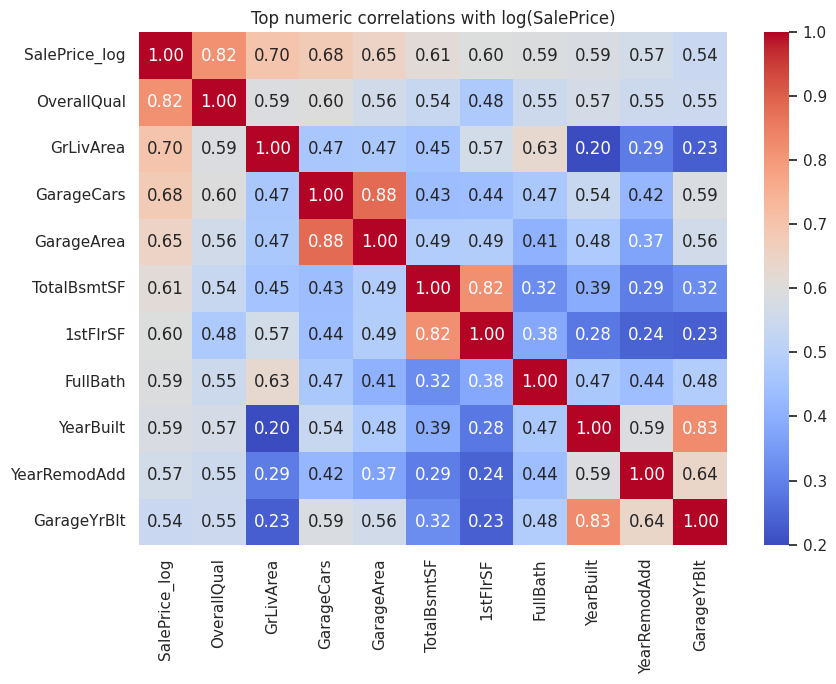

In [49]:
numeric_for_corr = train.select_dtypes(include=np.number).drop(columns=["Id", "SalePrice"])
corr = numeric_for_corr.assign(SalePrice_log=y_log).corr()
top_features = corr["SalePrice_log"].abs().sort_values(ascending=False).head(11).index

plt.figure(figsize=(9, 7))
sns.heatmap(corr.loc[top_features, top_features], annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Top numeric correlations with log(SalePrice)")
plt.tight_layout()
plt.show()

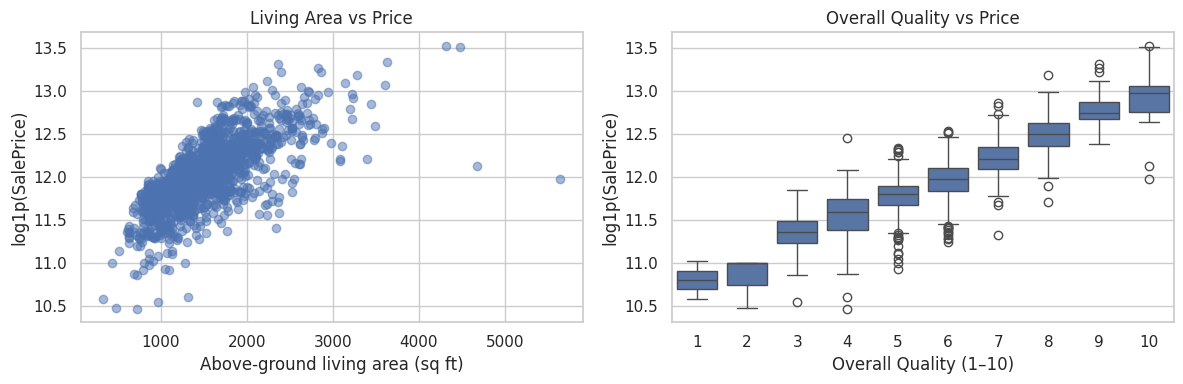

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(train["GrLivArea"], y_log, alpha=0.5)
axes[0].set_xlabel("Above-ground living area (sq ft)")
axes[0].set_ylabel("log1p(SalePrice)")
axes[0].set_title("Living Area vs Price")

sns.boxplot(x=train["OverallQual"], y=y_log, ax=axes[1])
axes[1].set_xlabel("Overall Quality (1–10)")
axes[1].set_ylabel("log1p(SalePrice)")
axes[1].set_title("Overall Quality vs Price")

plt.tight_layout()
plt.show()

## 6. Train/Validation Split

The data is split before preprocessing. This ensures that imputation values and encoding categories are learned from the training set only, which helps prevent data leakage.


In [51]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_log, test_size=0.20, random_state=RANDOM_STATE
)

print("Training rows:", X_train.shape[0])
print("Validation rows:", X_val.shape[0])

Training rows: 1168
Validation rows: 292


## 7. Encoding Strategy: Ordinal vs Nominal

Encoding is chosen based on the meaning of each feature.

### Ordinal encoding
Used when categories have a natural order, such as quality or condition ratings. The encoding preserves that order.

### One-hot encoding
Used for nominal categories with no natural ranking, such as neighborhood or foundation type. Each category becomes a separate binary feature.


In [52]:
# Define ordered categories from lowest/absent to highest.
quality_order = ["None", "Po", "Fa", "TA", "Gd", "Ex"]
ordinal_categories = {
    "ExterQual": quality_order,
    "ExterCond": quality_order,
    "BsmtQual": quality_order,
    "BsmtCond": quality_order,
    "HeatingQC": quality_order,
    "KitchenQual": quality_order,
    "FireplaceQu": quality_order,
    "GarageQual": quality_order,
    "GarageCond": quality_order,
    "PoolQC": quality_order,
    "BsmtExposure": ["None", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "GarageFinish": ["None", "Unf", "RFn", "Fin"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "PavedDrive": ["N", "P", "Y"],
    "LotShape": ["IR3", "IR2", "IR1", "Reg"],
    "LandSlope": ["Sev", "Mod", "Gtl"],
    "Utilities": ["ELO", "NoSeWa", "NoSewr", "AllPub"]
}

ordinal_cols = list(ordinal_categories.keys())

# Treat remaining categorical features as nominal.
categorical_cols = X.select_dtypes(include="object").columns.tolist()
nominal_cols = [c for c in categorical_cols if c not in ordinal_cols]

# Keep only columns that exist in the current dataset.
ordinal_cols = [c for c in ordinal_cols if c in X.columns]
nominal_cols = [c for c in nominal_cols if c in X.columns]

numeric_cols = [c for c in X.columns if c not in ordinal_cols + nominal_cols]

print("Ordinal columns:", len(ordinal_cols))
print(ordinal_cols)
print("\nNominal columns:", len(nominal_cols))
print(nominal_cols)
print("\nNumeric columns:", len(numeric_cols))

Ordinal columns: 19
['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'Functional', 'PavedDrive', 'LotShape', 'LandSlope', 'Utilities']

Nominal columns: 25
['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

Numeric columns: 36


In [53]:
# Separate absence categories from ordinary missing categorical values.
ordinal_absence_cols = [c for c in ordinal_cols if c in absence_categorical]
ordinal_regular_cols = [c for c in ordinal_cols if c not in absence_categorical]
nominal_absence_cols = [c for c in nominal_cols if c in absence_categorical]
nominal_regular_cols = [c for c in nominal_cols if c not in absence_categorical]

# Numeric absence columns are filled with zero; other numeric missing values use the median.
numeric_absence_cols = [c for c in numeric_cols if c in absence_numeric]
numeric_regular_cols = [c for c in numeric_cols if c not in absence_numeric]

print("Ordinal absence:", ordinal_absence_cols)
print("Nominal absence:", nominal_absence_cols)
print("Numeric absence:", numeric_absence_cols)

Ordinal absence: ['BsmtQual', 'BsmtCond', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish']
Nominal absence: ['Alley', 'MasVnrType', 'GarageType', 'Fence', 'MiscFeature']
Numeric absence: ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea']


### Build the leakage-safe preprocessing pipeline

The `SimpleImputer` steps are fitted only on the training split. The `OrdinalEncoder` receives the explicit order for each ranked variable, while `OneHotEncoder` handles nominal variables. `MSSubClass` is already included in `nominal_cols` because its semantic type was corrected above.

#### Why this preprocessing? 

* Different features need different treatment. Missing garage or basement values can mean the feature does not exist, so these are filled with 0 or None. Other missing values are estimated using the median or most common category.

* Ordered categories use ordinal encoding so their ranking is preserved. Nominal categories use one-hot encoding because their categories have no natural order.

* The preprocessing is fitted only on the training data, then applied to validation and test data. This prevents information from the validation or test sets from influencing the model.

In [54]:
transformers = []

if numeric_absence_cols:
    transformers.append((
        "numeric_absence",
        Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value=0))]),
        numeric_absence_cols
    ))

if numeric_regular_cols:
    transformers.append((
        "numeric_regular",
        Pipeline([("imputer", SimpleImputer(strategy="median"))]),
        numeric_regular_cols
    ))

if ordinal_absence_cols:
    transformers.append((
        "ordinal_absence",
        Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
            ("encoder", OrdinalEncoder(
                categories=[ordinal_categories[c] for c in ordinal_absence_cols],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ))
        ]),
        ordinal_absence_cols
    ))

if ordinal_regular_cols:
    transformers.append((
        "ordinal_regular",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(
                categories=[ordinal_categories[c] for c in ordinal_regular_cols],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ))
        ]),
        ordinal_regular_cols
    ))

if nominal_absence_cols:
    transformers.append((
        "nominal_absence",
        Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
        ]),
        nominal_absence_cols
    ))

if nominal_regular_cols:
    transformers.append((
        "nominal_regular",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
        ]),
        nominal_regular_cols
    ))

preprocessor = ColumnTransformer(transformers=transformers, remainder="drop", verbose_feature_names_out=False)

# Fit preprocessing on the training split and apply the same rules to validation and test data.
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_val_processed = pd.DataFrame(X_val_processed, columns=feature_names, index=X_val.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)
print("Any missing values after preprocessing:", X_train_processed.isna().sum().sum())

Processed training shape: (1168, 217)
Processed validation shape: (292, 217)
Processed test shape: (1459, 217)
Any missing values after preprocessing: 0


## 8. Model Evaluation

I compare two models on the same validation set:

- **Linear Regression** — a simple, interpretable baseline.
- **Random Forest** — a nonlinear model that can capture more complex feature relationships.

Evaluation uses:
- **RMSE on log prices** — the main competition metric.
- **R²** — how much variation in the target is explained.
- **MAE in price units** — easier to interpret in real-world terms.


In [55]:
model_lr = LinearRegression()
model_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model_lr.fit(X_train_processed, y_train)
model_rf.fit(X_train_processed, y_train)

pred_val_lr = model_lr.predict(X_val_processed)
pred_val_rf = model_rf.predict(X_val_processed)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE (log price)": [
        np.sqrt(mean_squared_error(y_val, pred_val_lr)),
        np.sqrt(mean_squared_error(y_val, pred_val_rf))
    ],
    "R²": [
        r2_score(y_val, pred_val_lr),
        r2_score(y_val, pred_val_rf)
    ],
    "MAE (price)": [
        mean_absolute_error(np.expm1(y_val), np.expm1(pred_val_lr)),
        mean_absolute_error(np.expm1(y_val), np.expm1(pred_val_rf))
    ]
})

display(results.round(4))

,Model,RMSE (log price),R²,MAE (price)
0,Linear Regression,0.2013,0.7828,15598.0225
1,Random Forest,0.1475,0.8834,17416.7633


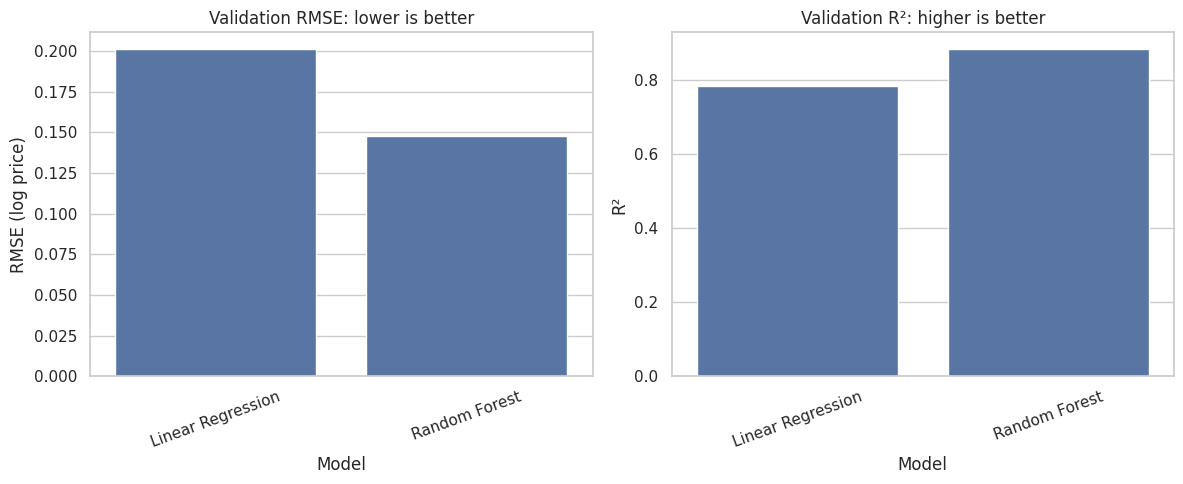

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=results, x="Model", y="RMSE (log price)", ax=axes[0])
axes[0].set_title("Validation RMSE: lower is better")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=results, x="Model", y="R²", ax=axes[1])
axes[1].set_title("Validation R²: higher is better")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

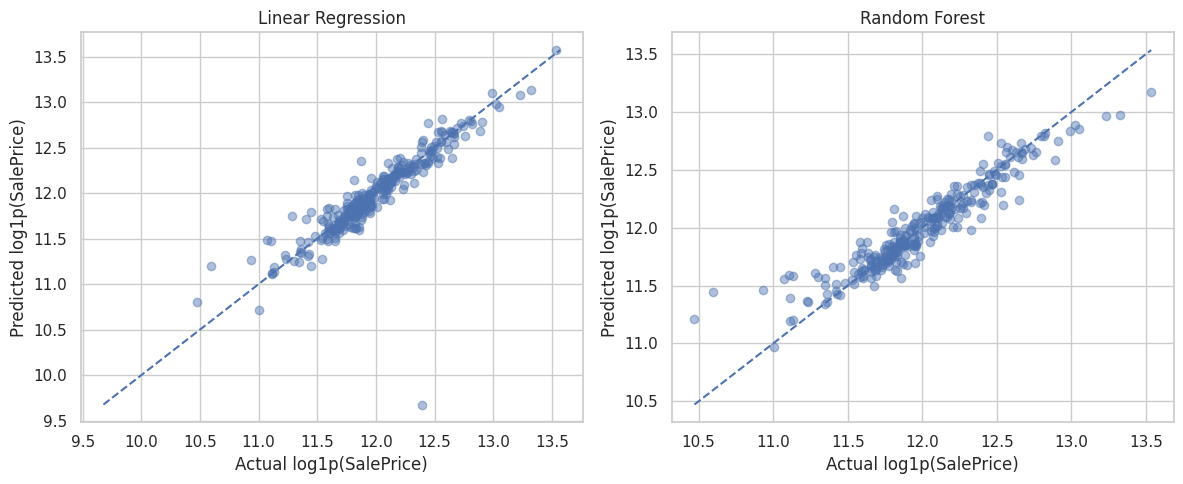

In [57]:
# Predicted-vs-actual plot for the two validation models.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title in [
    (axes[0], pred_val_lr, "Linear Regression"),
    (axes[1], pred_val_rf, "Random Forest")
]:
    ax.scatter(y_val, pred, alpha=0.45)
    low = min(y_val.min(), pred.min())
    high = max(y_val.max(), pred.max())
    ax.plot([low, high], [low, high], "--")
    ax.set_xlabel("Actual log1p(SalePrice)")
    ax.set_ylabel("Predicted log1p(SalePrice)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 10. Final Model and Test Prediction

I select the model with the lowest validation RMSE, retrain it on all labelled training data, and generate predictions for the test set.

The final predictions are converted back from the log scale and saved for submission.


In [58]:
best_model_name = results.loc[results["RMSE (log price)"].idxmin(), "Model"]
print("Selected model:", best_model_name)

# Refit preprocessing on all labelled rows now that model selection is complete.
X_all_processed = preprocessor.fit_transform(X)
X_test_final_processed = preprocessor.transform(X_test)
final_feature_names = preprocessor.get_feature_names_out()

X_all_processed = pd.DataFrame(X_all_processed, columns=final_feature_names, index=X.index)
X_test_final_processed = pd.DataFrame(X_test_final_processed, columns=final_feature_names, index=X_test.index)

if best_model_name == "Random Forest":
    final_model = RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
else:
    final_model = LinearRegression()

final_model.fit(X_all_processed, y_log)
final_pred_log = final_model.predict(X_test_final_processed)
final_pred = np.maximum(0, np.expm1(final_pred_log))

print("Final prediction count:", len(final_pred))
print("First 10 predictions:")
print(final_pred[:10])

Selected model: Random Forest
Final prediction count: 1459
First 10 predictions:
[124176.70807356 151023.8999137  180539.69387725 180549.67912122
 197579.14613579 183218.59613641 162908.88268924 176403.06832696
 186000.61658459 123433.32550443]


In [ ]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": final_pred
})

submission.to_csv("submission.csv", index=False)
submission.head()

## 11. Final Checks

Before creating the submission, I check the column names, row count and prediction values to make sure the output is ready for Kaggle.


In [ ]:
assert list(submission.columns) == ["Id", "SalePrice"]
assert len(submission) == len(test)
assert submission["SalePrice"].notna().all()
assert (submission["SalePrice"] >= 0).all()

print("Submission checks passed.")
print("Rows:", len(submission))
print("Columns:", list(submission.columns))
print("Missing predictions:", submission["SalePrice"].isna().sum())

## Summary

This workflow applies feature engineering based on the meaning of each variable.

- Missing values are handled according to whether a feature is absent or unknown.
- `MSSubClass` is treated as categorical.
- Ordered categories use ordinal encoding.
- Nominal categories use one-hot encoding.
- Preprocessing is learned from the training split to avoid leakage.
- Linear Regression and Random Forest are compared using relevant metrics.
- The best model is retrained on all labelled data and used to create `submission.csv`.

**Key idea:** choose the preprocessing method based on the meaning of the feature, not just its data type.
